In [13]:
import sunpy
import sunpy.map
import numpy as np
from math import *
import astropy.units as u
from astropy.io import fits
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sunpy.coordinates import frames
import matplotlib.gridspec as gridspec
from scipy.interpolate import interp1d,RegularGridInterpolator
from astropy.coordinates import SkyCoord
from matplotlib.patches import ConnectionPatch
import os,cv2
from scipy.optimize import fmin
from scipy.ndimage import affine_transform
import shutil
from scipy.io import readsav
import glob
from matplotlib.patches import Rectangle
from scipy.ndimage import zoom
from matplotlib.colors import Normalize,LogNorm
import matplotlib.ticker as ticker
from scipy.ndimage import gaussian_filter1d
from sunpy.coordinates import Helioprojective, SphericalScreen, propagate_with_solar_surface
from astropy.wcs import WCS

__<font color=cyan>画双云模型</font>__

6561.305598407436 6561.5480186241975 6562.032859057719 6564.069188878513 6564.3116090952735


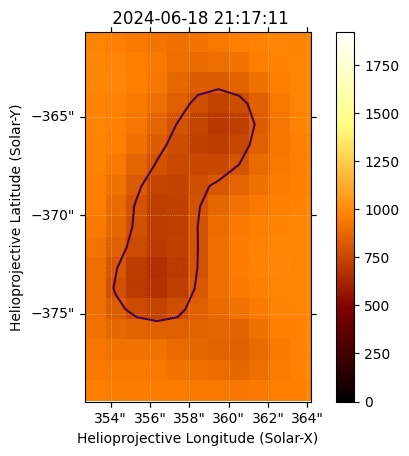

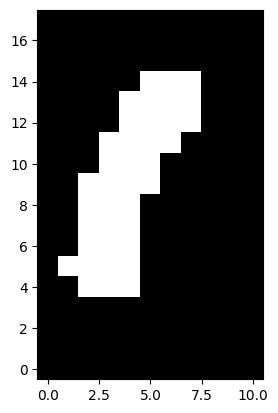

In [9]:
#数据准备
dir=r'C:\Learning\PHD1st\magnetic_reconnecion\data\CHASE_Ha\RSM20240618T211711_0000_HA.fits'
rsm=fits.open(dir)
left_index=44
right_index=96
lam00 = rsm[1].header['CRVAL3'] + np.arange(rsm[1].header['NAXIS3']) * rsm[1].header['CDELT3']
lam=lam00[left_index:right_index]#±1.5A
I0=rsm[1].data[left_index:right_index,797:826,1540:1569].mean(axis=(1,2))
print(lam00[39],lam00[44],lam00[54],lam00[96],lam00[101])

hawing = rsm[1].data[44:54, :, :].mean(axis=0)
coord_HIS = SkyCoord(0 * u.arcsec, 0 * u.arcsec, obstime = '2024-06-18 21:17:11', observer = 'earth', \
                     frame = frames.Helioprojective)
headerwing = sunpy.map.make_fitswcs_header(hawing, coord_HIS,
                                       reference_pixel = \
                                       [rsm[1].header['CRPIX1'], rsm[1].header['CRPIX2']] * u.pixel,
                                       scale = [0.5218 * 2, 0.5218 * 2] * u.arcsec / u.pixel,
                                       telescope = 'CHASE', instrument = 'RSM')
#生成的蓝翼图像
hawing_map = sunpy.map.Map(hawing, headerwing)

left_bottom=SkyCoord(Tx=200*u.arcsec,Ty=-520*u.arcsec,frame=hawing_map.coordinate_frame)
top_right=SkyCoord(Tx=420*u.arcsec,Ty=-300*u.arcsec,frame=hawing_map.coordinate_frame)
sub_hawing_map=hawing_map.submap(left_bottom,top_right=top_right)

fig=plt.figure()
jet_point4=(1515,789)
point4=hawing_map.wcs.pixel_to_world(jet_point4[0],jet_point4[1])
jet_point5=(1525,806)
point5=hawing_map.wcs.pixel_to_world(jet_point5[0],jet_point5[1])
jet_region=sub_hawing_map.submap(point4,top_right=point5)
ax3=fig.add_subplot(projection=jet_region)
im=jet_region.plot(axes=ax3,cmap='afmhot',vmin=0, vmax = 2 * sub_hawing_map.data.mean())
cbar=fig.colorbar(im,ax=ax3)
contour=ax3.contour(jet_region.data,levels=[800],transform=ax3.get_transform(jet_region.wcs))

#-------------------------------------------------------------------------------------------
#由contour生成mask
cs = contour
from matplotlib.path import Path
# 初始化 mask
mask = np.zeros_like(jet_region.data, dtype=bool)

# 构造像素坐标网格
ny, nx = jet_region.data.shape
X, Y = np.meshgrid(np.arange(nx), np.arange(ny))
points = np.vstack((X.flatten(), Y.flatten())).T  # (N, 2)

# 遍历所有封闭区域
for path in cs.get_paths():
    poly = Path(path.vertices)
    mask |= poly.contains_points(points).reshape(ny, nx)
# 现在 mask 就是一个布尔数组，True 表示在等值线包围区域内
plt.figure()
plt.imshow(mask, origin='lower', cmap='gray')
#plt.title("等值线区域 mask")
plt.show()

run 01/30, seed=20260706, raw_sse=2890.51, scaled_sse=0.0912191
run 02/30, seed=20260707, raw_sse=1926.29, scaled_sse=0.0607902
run 03/30, seed=20260708, raw_sse=2890.51, scaled_sse=0.0912191
run 04/30, seed=20260709, raw_sse=1926.29, scaled_sse=0.0607902
run 05/30, seed=20260710, raw_sse=1926.29, scaled_sse=0.0607902
run 06/30, seed=20260711, raw_sse=2890.51, scaled_sse=0.0912191
run 07/30, seed=20260712, raw_sse=622.177, scaled_sse=0.0196347
run 08/30, seed=20260713, raw_sse=3872.29, scaled_sse=0.122202
run 09/30, seed=20260714, raw_sse=1926.29, scaled_sse=0.0607902
run 10/30, seed=20260715, raw_sse=1926.29, scaled_sse=0.0607902
run 11/30, seed=20260716, raw_sse=1926.29, scaled_sse=0.0607902
run 12/30, seed=20260717, raw_sse=3161.95, scaled_sse=0.099785
run 13/30, seed=20260718, raw_sse=2906.83, scaled_sse=0.0917339
run 14/30, seed=20260719, raw_sse=622.177, scaled_sse=0.0196347
run 15/30, seed=20260720, raw_sse=622.177, scaled_sse=0.0196347
run 16/30, seed=20260721, raw_sse=2153.44,

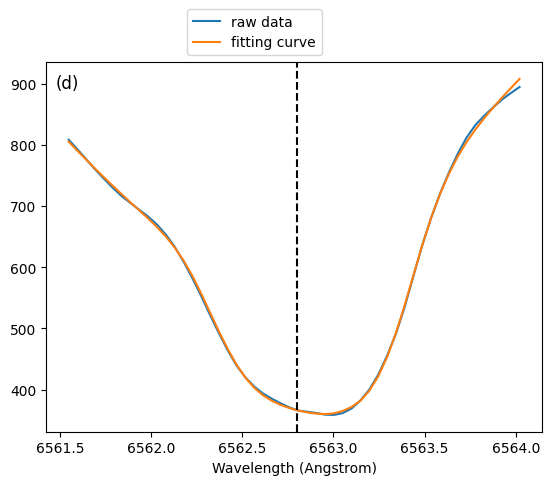

In [10]:
#把mask应用到数据上，得到目标区域的平均光谱曲线
data_jet=rsm[1].data[left_index:right_index,789:807,1515:1526]
data_mask=np.tile(~mask,(right_index-left_index,1,1))
jet_masked=np.ma.array(data_jet,mask=data_mask)
spec_data=jet_masked.mean(axis=(1,2))

import numpy as np
from functools import partial
from scipy.optimize import differential_evolution, least_squares
import matplotlib.pyplot as plt

lam0 = 6562.8
c_km = 299792.458

# wavelength -> velocity
lam = lam00[left_index:right_index]
vel = (lam - lam0) / lam0 * c_km

I = spec_data
I0 = rsm[1].data[left_index:right_index, 797:826, 1540:1569].mean(axis=(1, 2))
Icont = I0

# =========================
# 1. 数据清理
# =========================
I_fit = np.ma.filled(I, np.nan)
Icont_fit = np.ma.filled(Icont, np.nan)

valid = np.isfinite(vel) & np.isfinite(I_fit) & np.isfinite(Icont_fit)

vel_fit = np.asarray(vel[valid], dtype=float)
I_fit = np.asarray(I_fit[valid], dtype=float)
Icont_fit = np.asarray(Icont_fit[valid], dtype=float)

# 用于残差归一化。只改变数值优化稳定性，不改变最优解位置。
sigma = np.std(I_fit - np.median(I_fit))
if not np.isfinite(sigma) or sigma <= 0:
    sigma = np.mean(np.abs(I_fit)) * 1e-3
if not np.isfinite(sigma) or sigma <= 0:
    sigma = 1.0


# =========================
# 2. 双云模型
# 参数: [ltauL, ltauU, vL, vU, lWl, lWu, SL, SU]
# =========================
def double_cloud_vel(params, vel, Icont):
    ltauL, ltauU, vL, vU, lWl, lWu, SL, SU = params

    tau0L = np.exp(ltauL)
    tau0U = np.exp(ltauU)
    WL = np.exp(lWl)
    WU = np.exp(lWu)

    tauL = tau0L * np.exp(-((vel - vL) ** 2) / (WL ** 2))
    tauU = tau0U * np.exp(-((vel - vU) ** 2) / (WU ** 2))

    I_model = (
        Icont * np.exp(-(tauL + tauU))
        + SL * (1 - np.exp(-tauL)) * np.exp(-tauU)
        + SU * (1 - np.exp(-tauU))
    )

    return I_model


def residuals_scaled(params, vel, I, Icont):
    return (double_cloud_vel(params, vel, Icont) - I) / sigma


def ssq_scaled(params, vel, I, Icont):
    r = residuals_scaled(params, vel, I, Icont)
    return np.sum(r ** 2)


def ssq_raw(params, vel, I, Icont):
    y = double_cloud_vel(params, vel, Icont)
    return np.sum((y - I) ** 2)


# =========================
# 3. 参数范围
# =========================
Imean = np.mean(I_fit)

# 如果出现极窄线宽吃噪声，可以把 W_MIN 改成 0.5 或 1.0
W_MIN = 0.05
W_MAX = 200.0

lb = np.array([
    np.log(1e-3), np.log(1e-3),   # ltauL, ltauU
    -200.0, -200.0,               # vL, vU
    np.log(W_MIN), np.log(W_MIN), # lWl, lWu
    0.0, 0.0                      # SL, SU
], dtype=float)

ub = np.array([
    np.log(1e2), np.log(1e2),
    200.0, 200.0,
    np.log(W_MAX), np.log(W_MAX),
    Imean * 10, Imean * 10
], dtype=float)

bounds = list(zip(lb, ub))


# =========================
# 4. 多次全局搜索 + 局部精炼
# =========================
N_GLOBAL_RUNS = 30
BASE_SEED = 20260706

candidates = []

for i in range(N_GLOBAL_RUNS):
    seed = BASE_SEED + i

    result_de = differential_evolution(
        ssq_scaled,
        bounds,
        args=(vel_fit, I_fit, Icont_fit),
        strategy='best1bin',
        maxiter=1500,
        popsize=25,
        tol=1e-8,
        atol=0.0,
        mutation=(0.5, 1.0),
        recombination=0.7,
        seed=seed,
        init='sobol',
        polish=False,
        updating='immediate',
        workers=1
    )

    # 用和 DE 完全一致的目标函数做局部精炼。
    # 注意这里不使用 soft_l1，因为 soft_l1 会改变优化目标。
    lsq = least_squares(
        residuals_scaled,
        result_de.x,
        args=(vel_fit, I_fit, Icont_fit),
        bounds=(lb, ub),
        loss='linear',
        x_scale=np.array([
            1.0, 1.0,       # ltauL, ltauU
            50.0, 50.0,     # vL, vU
            1.0, 1.0,       # lWl, lWu
            max(Imean, 1), max(Imean, 1)
        ]),
        ftol=1e-12,
        xtol=1e-12,
        gtol=1e-12,
        max_nfev=10000
    )

    scaled_sse = ssq_scaled(lsq.x, vel_fit, I_fit, Icont_fit)
    raw_sse = ssq_raw(lsq.x, vel_fit, I_fit, Icont_fit)

    candidates.append({
        "seed": seed,
        "x": lsq.x,
        "raw_sse": raw_sse,
        "scaled_sse": scaled_sse,
        "de_fun": result_de.fun,
        "lsq_cost": lsq.cost,
        "success": lsq.success,
        "message": lsq.message
    })

    print(
        f"run {i + 1:02d}/{N_GLOBAL_RUNS}, "
        f"seed={seed}, raw_sse={raw_sse:.6g}, scaled_sse={scaled_sse:.6g}"
    )


# =========================
# 5. 选择最优候选
# =========================
candidates = sorted(candidates, key=lambda d: d["raw_sse"])
best = candidates[0]
x_opt = best["x"]

print("\n===== best candidate =====")
print("best seed:", best["seed"])
print("best raw SSE:", best["raw_sse"])
print("best scaled SSE:", best["scaled_sse"])
print("least_squares success:", best["success"])
print("least_squares message:", best["message"])

print("\n===== top 5 candidates =====")
for k, cand in enumerate(candidates[:5], start=1):
    print(
        f"{k}: seed={cand['seed']}, "
        f"raw_sse={cand['raw_sse']:.8g}, "
        f"scaled_sse={cand['scaled_sse']:.8g}"
    )


# =========================
# 6. 拆解结果
# =========================
ltauL, ltauU, vL, vU, lWl, lWu, SL, SU = x_opt

tau0L = np.exp(ltauL)
tau0U = np.exp(ltauU)
WL = np.exp(lWl)
WU = np.exp(lWu)

print("\n===== fitted parameters =====")
print(f"SL={SL:.6g}, SU={SU:.6g}")
print(f"tau0L={tau0L:.6g}, tau0U={tau0U:.6g}")
print(f"vL={vL:.6g} km/s, vU={vU:.6g} km/s")
print(f"WL={WL:.6g} km/s, WU={WU:.6g} km/s")


# =========================
# 7. 作图
# =========================
y_fit = double_cloud_vel(x_opt, vel, Icont)

print("\n拟合误差:", np.sum((np.ma.filled(I, np.nan) - y_fit) ** 2))

fig, ax = plt.subplots()
ax.plot(lam, I, label='raw data')
ax.plot(lam, y_fit, label='fitting curve')
ax.text(0.02, 0.93, '(d)', color='black', transform=ax.transAxes, fontsize=12)
ax.axvline(lam0, linestyle='--', color='black')
ax.legend(bbox_to_anchor=(0.27, 1))
ax.set_xlabel('Wavelength (Angstrom)')
plt.show()

In [11]:
np.save('x_opt_new.npy',x_opt)

6561.305598407436 6561.5480186241975 6562.032859057719 6564.069188878513 6564.3116090952735
宁静区左下角的位置  y:797.58,x:1540.66
宁静区右上角的位置  y:826.32,x:1569.41
喷流点选取的位置  y:791.00,x:1520.00
喷流选取的位置  y:789.00,x:1515.00
喷流选取的位置  y:806.00,x:1525.00
vL= -15.66921234951098 km/s vU= 20.54882393973615 km/s


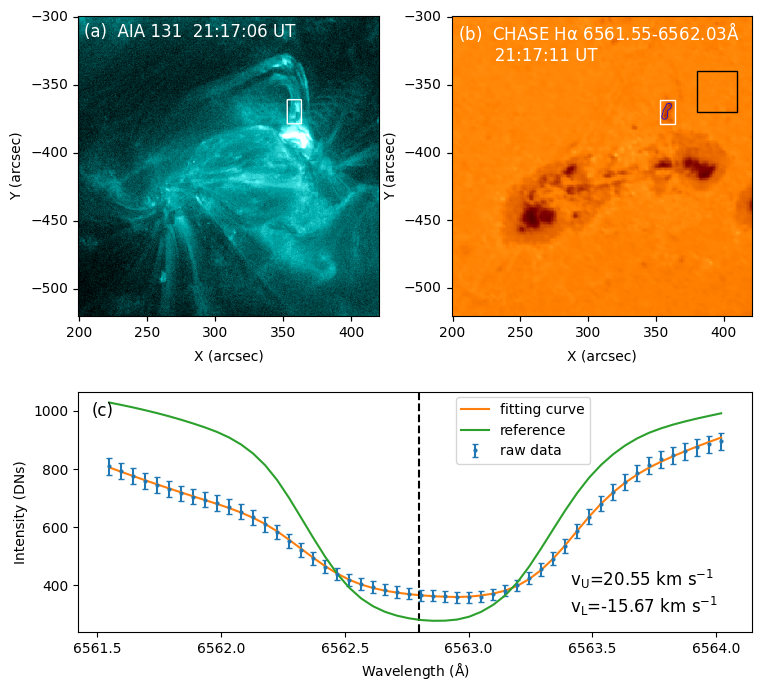

In [12]:
def double_cloud_vel(params, vel, Icont):
    ltauL, ltauU, vL, vU, lWl, lWu, SL, SU = params
    tau0L = np.exp(ltauL)
    tau0U = np.exp(ltauU)
    WL = np.exp(lWl)
    WU = np.exp(lWu)
    
    tauL = tau0L * np.exp(-((vel - vL)**2) / (WL**2))
    tauU = tau0U * np.exp(-((vel - vU)**2) / (WU**2))
    
    I = Icont * np.exp(-(tauL + tauU)) \
        + SL * (1 - np.exp(-tauL)) * np.exp(-tauU) \
        + SU * (1 - np.exp(-tauU))
    return I,vL,vU


import matplotlib as mpl
mpl.rcParams['text.usetex'] = False

# 数据准备
dir = r'C:\Learning\PHD1st\magnetic_reconnecion\data\CHASE_Ha\RSM20240618T211711_0000_HA.fits'
rsm = fits.open(dir)

left_index = 44
right_index = 96
lam00 = rsm[1].header['CRVAL3'] + np.arange(rsm[1].header['NAXIS3']) * rsm[1].header['CDELT3']
lam = lam00[left_index:right_index]  # ±1.5A
I0 = rsm[1].data[left_index:right_index, 797:826, 1540:1569].mean(axis=(1, 2))

print(lam00[39], lam00[44], lam00[54], lam00[96], lam00[101])

lam0 = 6562.8
c_km = 299792.458
vel = (lam - lam0) / lam0 * c_km  # km/s

# 画图
hawing = rsm[1].data[44:54, :, :].mean(axis=0)
coord_HIS = SkyCoord(0 * u.arcsec, 0 * u.arcsec, obstime='2024-06-18 21:17:11', observer='earth', frame=frames.Helioprojective)
headerwing = sunpy.map.make_fitswcs_header(hawing, coord_HIS, reference_pixel=[rsm[1].header['CRPIX1'], rsm[1].header['CRPIX2']] * u.pixel, scale=[0.5218 * 2, 0.5218 * 2] * u.arcsec / u.pixel, telescope='CHASE', instrument='RSM')
hawing_map = sunpy.map.Map(hawing, headerwing)

left_bottom = SkyCoord(Tx=200 * u.arcsec, Ty=-520 * u.arcsec, frame=hawing_map.coordinate_frame)
top_right = SkyCoord(Tx=420 * u.arcsec, Ty=-300 * u.arcsec, frame=hawing_map.coordinate_frame)
sub_hawing_map = hawing_map.submap(left_bottom, top_right=top_right)

# aia131 图像
dir2 = r'C:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\131\aia.lev1_euv_12s.2024-06-18T211708Z.131.image_lev1.fits'
aia = sunpy.map.Map(dir2)

left_bottom = SkyCoord(Tx=200 * u.arcsec, Ty=-520 * u.arcsec, frame=aia.coordinate_frame)
top_right = SkyCoord(Tx=420 * u.arcsec, Ty=-300 * u.arcsec, frame=aia.coordinate_frame)
sub_aia = aia.submap(left_bottom, top_right=top_right)

# ----------------------------------------------------------------------------------------------------------------------------
# 图1
fig = plt.figure(figsize=(9, 8))
gs = gridspec.GridSpec(2, 1, hspace=0.28, height_ratios=[1, 0.8])
gs_top = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs[0], wspace=0.15, width_ratios=[1, 1])

old_norm = sub_aia.plot_settings['norm']
old_norm.vmin = 0.01
old_norm.vmax = 2000

ax1 = fig.add_subplot(gs_top[0], projection=sub_aia)
sub_aia.plot(axes=ax1, norm=old_norm)

# ------------------------------------------------------------------------------------------------------------------
# 图2
ax2 = fig.add_subplot(gs_top[1], projection=sub_hawing_map)
sub_hawing_map.plot(axes=ax2, cmap='afmhot', vmin=0, vmax=2 * sub_hawing_map.data.mean())

# point1 是宁静区左下角
point1 = SkyCoord(Tx=380 * u.arcsec, Ty=-370 * u.arcsec, frame=hawing_map.coordinate_frame)
xpix1, ypix1 = hawing_map.world_to_pixel(point1)
print(f'宁静区左下角的位置  y:{ypix1.value:.2f},x:{xpix1.value:.2f}')

# point2 是宁静区右上角
point2 = SkyCoord(Tx=410 * u.arcsec, Ty=-340 * u.arcsec, frame=hawing_map.coordinate_frame)
xpix2, ypix2 = hawing_map.world_to_pixel(point2)
print(f'宁静区右上角的位置  y:{ypix2.value:.2f},x:{xpix2.value:.2f}')

sub_hawing_map.draw_quadrangle(point1, top_right=point2, axes=ax2, edgecolor='black')

jet_point = (1520, 791)
point3 = hawing_map.wcs.pixel_to_world(jet_point[0], jet_point[1])
xpix3, ypix3 = hawing_map.world_to_pixel(point3)
print(f'喷流点选取的位置  y:{ypix3.value:.2f},x:{xpix3.value:.2f}')

# point4 是喷流选取左下角
jet_point4 = (1515, 789)
point4 = hawing_map.wcs.pixel_to_world(jet_point4[0], jet_point4[1])
xpix4, ypix4 = hawing_map.world_to_pixel(point4)
print(f'喷流选取的位置  y:{ypix4.value:.2f},x:{xpix4.value:.2f}')

# point5 是喷流选取右上角
jet_point5 = (1525, 806)
point5 = hawing_map.wcs.pixel_to_world(jet_point5[0], jet_point5[1])
xpix5, ypix5 = hawing_map.world_to_pixel(point5)
print(f'喷流选取的位置  y:{ypix5.value:.2f},x:{xpix5.value:.2f}')

sub_hawing_map.draw_quadrangle(point4, top_right=point5, axes=ax2, edgecolor='white')
sub_aia.draw_quadrangle(point4, top_right=point5, axes=ax1, edgecolor='white')

# 喷流小区域
jet_region = sub_hawing_map.submap(point4, top_right=point5)

# b 图中显示 contour
contour_b = ax2.contour(jet_region.data, levels=[800], colors=['blue'], linewidths=0.5, transform=ax2.get_transform(jet_region.wcs))

# -------------------------------------------------------------------------------------------------
# 关键：不画原来的 C 小图，但仍然用 jet_region.data 生成一个 contour 来算 mask/raw data
from matplotlib.path import Path

fig_tmp, ax_tmp = plt.subplots()
contour_for_mask = ax_tmp.contour(jet_region.data, levels=[800], colors=['blue'],linewidths=1)
plt.close(fig_tmp)

mask = np.zeros_like(jet_region.data, dtype=bool)

ny, nx = jet_region.data.shape
X, Y = np.meshgrid(np.arange(nx), np.arange(ny))
points = np.vstack((X.flatten(), Y.flatten())).T

for path in contour_for_mask.get_paths():
    poly = Path(path.vertices)
    mask |= poly.contains_points(points).reshape(ny, nx)

data_jet = rsm[1].data[left_index:right_index, 789:807, 1515:1526]
data_mask = np.tile(~mask, (right_index - left_index, 1, 1))
jet_masked = np.ma.array(data_jet, mask=data_mask)
I = jet_masked.mean(axis=(1, 2))

# -------------------------------------------------------------------------------------------------
# 新图3：原来的 D 图，现在变成 C 图，占据下面整行
ax3 = fig.add_subplot(gs[1])

x_opt = np.load('x_opt_new.npy')

ax3.errorbar(lam, I, yerr=np.sqrt(I), fmt='o', capsize=2, markersize=2, label='raw data')
y_fit,vL,vU = double_cloud_vel(x_opt, vel, I0)
ax3.plot(lam, y_fit, label='fitting curve')
ax3.axvline(x=6562.8, linestyle='--', color='black')
ax3.set_xlabel(r'Wavelength $(\mathrm{\AA})$')
ax3.set_ylabel('Intensity (DNs)')
ax3.plot(lam,I0,label='reference')
ax3.legend(bbox_to_anchor=(0.55, 0.67))

# ---------------------------------------------------------------------------------------------------
# 画图乱七八糟的部分
ax_all = [ax1, ax2]

for ax in ax_all:
    ax.set_xlabel('X (arcsec)', labelpad=1.2)
    ax.set_ylabel('Y (arcsec)')
    ax.tick_params(axis='x', which='both', bottom=True, labelbottom=True, top=False, labeltop=False)
    ax.tick_params(axis='y', which='both', left=True, labelleft=True, right=False, labelright=False)
    ax.coords[0].grid(draw_grid=False)
    ax.coords[1].grid(draw_grid=False)
    ax.coords[0].set_major_formatter('s', show_decimal_unit=False)
    ax.coords[1].set_major_formatter('s', show_decimal_unit=False)
    ax.set_title('')

ax_all[0].text(0.02, 0.93, '(a)  AIA 131  21:17:06 UT', color='white', transform=ax_all[0].transAxes, fontsize=12)
ax_all[1].text(0.02, 0.85, r'(b)  CHASE H$\mathrm{\alpha}$ 6561.55-6562.03$\mathrm{\AA}$' + 
               '\n       21:17:11 UT', color='white', transform=ax_all[1].transAxes, fontsize=12)

ax3.text(0.02, 0.9, '(c)', color='black', transform=ax3.transAxes, fontsize=12)
ax3.text(0.73, 0.08, r'$\mathrm{v_U}$' + f'={vU:.2f} ' + r'$\mathrm{km \ s^{-1}}$' + '\n'
          + r'$\mathrm{v_L} $' + f'={vL:.2f} ' + r'$\mathrm{km \ s^{-1}}$', color='black', fontsize=12, transform=ax3.transAxes)
# ---------- 让(c)图左右边界与(a)(b)总宽度对齐 ----------
fig.canvas.draw()

pos1 = ax1.get_position()
pos2 = ax2.get_position()
pos3 = ax3.get_position()

left = pos1.x0
right = pos2.x1

ax3.set_position([
    left,
    pos3.y0,
    right - left,
    pos3.height
])
print('vL=',vL,'km/s','vU=',vU,'km/s')
plt.savefig(r'C:\Learning\PHD1st\magnetic_reconnecion\paper\fig6\double_cloud.pdf', format='pdf', bbox_inches='tight', pad_inches=0.1)

__<font color=cyan>画DEM图</font>__

离太阳的距离是 151963569604.3406 m
一角秒对应多少千米是 736.7401757413695 km/arc
分辨率是 0.600697994 arc/pixel
尺寸是 2164.5785643123554 km/pixel


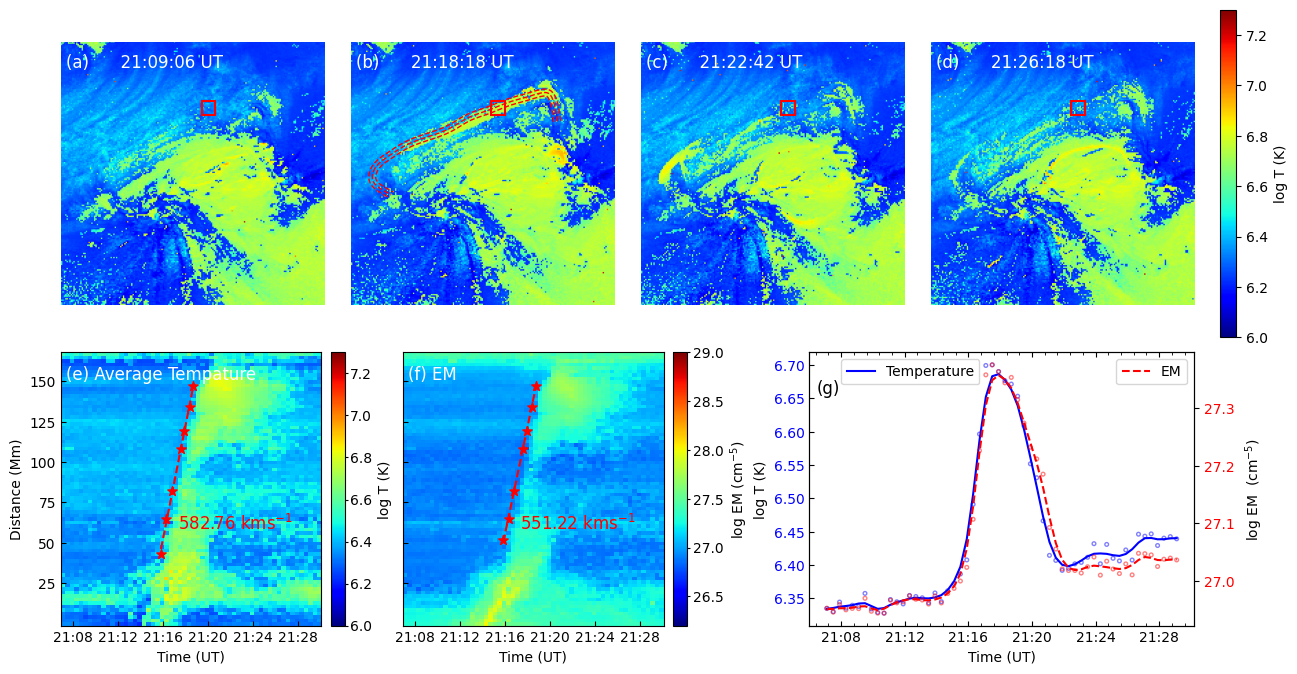

In [ ]:
data = np.load(r'C:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\fit_points.npz')
slice = np.load(r'C:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\result_matrix.npy')
slice_em = np.load(r'C:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\result_matrix_em.npy')

a = data['fit_points']
b = data['fit_points2']
c = data['fit_points3']

dist1 = np.average(np.sqrt(np.diff(a[:, 0])**2 + np.diff(a[:, 1])**2))
dist2 = np.average(np.sqrt(np.diff(b[:, 0])**2 + np.diff(b[:, 1])**2))
dist3 = np.average(np.sqrt(np.diff(c[:, 0])**2 + np.diff(c[:, 1])**2))
avg_diff = np.average([dist1, dist2, dist3])

rsm = fits.open(r'C:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\131\aia.lev1_euv_12s.2024-06-18T210044Z.131.image_lev1.fits')
dsun_obs = rsm[1].header['DSUN_OBS']
resolution = rsm[1].header['CDELT2']
k = sin(np.pi / (3600 * 180)) * dsun_obs / 1000
dist = k * resolution * avg_diff

print('离太阳的距离是',dsun_obs,'m')
print('一角秒对应多少千米是',k,'km/arc')
print('分辨率是',resolution,'arc/pixel')
print('尺寸是',dist,'km/pixel')

trans_coeff = dist * 1e-3#转化成Mm
corr_y = np.zeros(6)
for i in range(len(corr_y)):#对应位置
    corr_y[i] = 25 * (i + 1) / trans_coeff

fig = plt.figure(figsize=(16, 8))
gs = gridspec.GridSpec(2, 1, height_ratios=[1.2, 1], hspace=0.05)

gs_top = gridspec.GridSpecFromSubplotSpec(1, 4, subplot_spec=gs[0], wspace=0.1)
im_list = []

file_list = glob.glob(r'C:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\DEM2\\' + '*.sav')

ax11 = fig.add_subplot(gs_top[0])
datas = readsav(file_list[10])
result = datas['result']
smap_temp = result['SMAP_TEMP'][0]
im = ax11.imshow(np.log10(smap_temp), vmin=6.0, vmax=7.3, cmap='jet', origin='lower')
im_list.append(im)
ax11.text(0.02, 0.9, '(a)      21:09:06 UT', color='white', transform=ax11.transAxes, fontsize=12)
ax11.add_patch(Rectangle((102, 138), 10, 10, edgecolor='red', facecolor='none', linewidth=1.5))
ax11.axis('off')

ax22 = fig.add_subplot(gs_top[1])
datas = readsav(file_list[56])
result = datas['result']
smap_temp = result['SMAP_TEMP'][0]
im = ax22.imshow(np.log10(smap_temp), vmin=6.0, vmax=7.3, cmap='jet', origin='lower')
im_list.append(im)
ax22.text(0.02, 0.9, '(b)      21:18:18 UT', color='white', transform=ax22.transAxes, fontsize=12)
ax22.plot(b[:, 1] / 2, b[:, 0] / 2, linestyle='--', color='red', linewidth=1)
ax22.plot(a[:, 1] / 2, a[:, 0] / 2, linestyle='--', color='red', linewidth=1)
ax22.plot(c[:, 1] / 2, c[:, 0] / 2, linestyle='--', color='red', linewidth=1)
ax22.add_patch(Rectangle((102, 138), 10, 10, edgecolor='red', facecolor='none', linewidth=1.5))
ax22.axis('off')

ax3 = fig.add_subplot(gs_top[2])
datas = readsav(file_list[78])
result = datas['result']
smap_temp = result['SMAP_TEMP'][0]
im = ax3.imshow(np.log10(smap_temp), vmin=6.0, vmax=7.3, cmap='jet', origin='lower')
im_list.append(im)
ax3.text(0.02, 0.9, '(c)      21:22:42 UT', color='white', transform=ax3.transAxes, fontsize=12)
ax3.add_patch(Rectangle((102, 138), 10, 10, edgecolor='red', facecolor='none', linewidth=1.5))
ax3.axis('off')

ax4 = fig.add_subplot(gs_top[3])
datas = readsav(file_list[96])
result = datas['result']
smap_temp = result['SMAP_TEMP'][0]
im = ax4.imshow(np.log10(smap_temp), vmin=6.0, vmax=7.3, cmap='jet', origin='lower')
im_list.append(im)
ax4.text(0.02, 0.9, '(d)      21:26:18 UT', color='white', transform=ax4.transAxes, fontsize=12)
ax4.add_patch(Rectangle((102, 138), 10, 10, edgecolor='red', facecolor='none', linewidth=1.5))
ax4.axis('off')

cbar = fig.colorbar(im_list[0], ax=[ax11, ax22, ax3, ax4],
                    orientation='vertical', fraction=0.046, pad=0.04)
cbar.set_label('log T (K)')
cbar_pos = cbar.ax.get_position()
cbar.ax.set_position([cbar_pos.x0 - 0.015, cbar_pos.y0, cbar_pos.width, cbar_pos.height])

gs_bottom = gridspec.GridSpecFromSubplotSpec(
    1, 3,
    subplot_spec=gs[1],
    width_ratios=[2, 2, 3],
    wspace=0.4,
    hspace=0.2
)

corr_x = np.zeros(6)
for i in range(len(corr_x)):
    corr_x[i] = (54 + i * 240) / 24 #现在的时间间隔是24秒
x_labels = ['21:08', '21:12', '21:16', '21:20', '21:24', '21:28']

ax5 = fig.add_subplot(gs_bottom[0])
im5 = ax5.imshow(np.log10(slice), cmap='jet', origin='lower',
                 vmin=6.0, vmax=7.3, aspect='auto')
cbar5 = fig.colorbar(im5, ax=ax5, orientation='vertical', fraction=0.046, pad=0.04)
cbar5.set_label('log T (K)')

coord = [(5.8 + 16, 20), (7 + 16, 30), (8.2 + 16, 38),
         (10.2 + 16, 50), (11 + 16, 55), (12.2 + 16, 62), (13 + 16, 68)]
x1, y1 = zip(*coord)
x1, y1 = np.array(x1), np.array(y1)
coeff1 = np.polyfit(x1, y1, 1)
poly1 = np.poly1d(coeff1)
v1=coeff1[0]*dist/24 #时间间隔是24s,乘上距离倍数后要除掉时间倍数
ax5.scatter(x=x1, y=y1, c='red', marker='*', s=50)
ax5.plot(x1, poly1(x1), c='red', linestyle='--')
ax5.text(0.45, 0.35, f'{v1:.2f}' + r'$\ \mathrm{km s^{-1}}$',
         fontsize=12, color='red', transform=ax5.transAxes)
ax5.set_yticks(ticks=corr_y, labels=['25', '50', '75', '100', '125', '150'])
ax5.set_ylabel('Distance (Mm)')
ax5.set_xlabel('Time (UT)')
ax5.set_xticks(ticks=corr_x, labels=x_labels)
ax5.tick_params(axis='both', direction='in')
ax5.text(0.02, 0.9, '(e) Average Tempature',
         color='white', transform=ax5.transAxes, fontsize=12)

ax6 = fig.add_subplot(gs_bottom[1])
im6 = ax6.imshow(np.log10(slice_em), cmap='jet', origin='lower',
                 vmin=26.2, vmax=29, aspect='auto')
cbar6 = fig.colorbar(im6, ax=ax6, orientation='vertical', fraction=0.046, pad=0.04)
cbar6.set_label('log EM ' + r'$(\text{cm}^{-5})$')

coord2 = [(5.8 + 16, 24), (7 + 16, 30), (8.2 + 16, 38),
          (10.2 + 16, 50), (11 + 16, 55), (12.2 + 16, 62), (13 + 16, 68)]
x2, y2 = zip(*coord2)
x2, y2 = np.array(x2), np.array(y2)
coeff2 = np.polyfit(x2, y2, 1)
poly2 = np.poly1d(coeff2)
v2 = coeff2[0] * dist / 24

ax6.scatter(x=x2, y=y2, c='red', marker='*', s=50)
ax6.plot(x2, poly2(x2), c='red', linestyle='--')
ax6.text(0.45, 0.35, f'{v2:.2f}' + r'$\ \mathrm{km s^{-1}}$',
         fontsize=12, color='red', transform=ax6.transAxes)
ax6.set_yticks(ticks=corr_y, labels=['25', '50', '75', '100', '125', '150'])
ax6.set_xticks(ticks=corr_x, labels=x_labels)
ax6.set_xlabel('Time (UT)')
ax6.set_ylabel('')
ax6.set_yticklabels([])
ax6.tick_params(axis='both', direction='in')
ax6.text(0.02, 0.9, '(f) EM',
         color='white', transform=ax6.transAxes, fontsize=12)

avg_temp_r2 = np.zeros(58)
avg_em_r2 = np.zeros(58)
for i in range(58):
    datas = readsav(file_list[i * 2])
    result = datas['result']
    smap_temp = result['SMAP_TEMP'][0]
    smap_em = result['SMAP_EM'][0]
    avg_temp_r2[i] = np.mean(smap_temp[138:148, 102:112])
    avg_em_r2[i] = np.mean(smap_em[138:148, 102:112])

logT_r2 = np.log10(avg_temp_r2)
logem_r2 = np.log10(avg_em_r2)

ax7 = fig.add_subplot(gs_bottom[2])
sigma = 1.2
alpha = 0.5

data_r2 = logT_r2[:56]
smoothed_r2 = gaussian_filter1d(data_r2, sigma=sigma)
ax7.plot(np.linspace(0, 55, 56), smoothed_r2, label='Temperature', color='blue')
ax7.scatter(np.linspace(0, 55, 56), logT_r2[:56],
            alpha=alpha, s=7, facecolor='none', edgecolor='blue')
ax7.tick_params(axis='y', labelcolor='blue')
ax7.set_ylabel('log T (K)')
ax7.set_xlabel('Time (UT)')
ax7.set_xticks(ticks=corr_x, labels=x_labels)
ax7.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax7.yaxis.set_minor_locator(ticker.NullLocator())
ax7.text(0.02, 0.85, '(g)', color='black', transform=ax7.transAxes, fontsize=12)
ax7.legend(loc='upper left', bbox_to_anchor=(0.065, 1))

ax77 = ax7.twinx()
data_em_r2 = logem_r2[:56]
smoothed_em_r2 = gaussian_filter1d(data_em_r2, sigma=sigma)
ax77.plot(np.linspace(0, 55, 56), smoothed_em_r2,
          label='EM', linestyle='--', color='red')
ax77.scatter(np.linspace(0, 55, 56), logem_r2[:56],
             alpha=alpha, s=7, facecolor='none', edgecolor='red')
ax77.set_ylabel('log EM  ' + r'$(\text{cm}^{-5})$')
ax77.tick_params(axis='y', labelcolor='red')
ax77.legend(loc='upper right')

ax7.tick_params(axis='x', which='both', direction='in', top=True)
ax7.tick_params(axis='y', which='both', direction='in')

# ---------- 手动调整下排布局，避免 ticks 混在一起 ----------
fig.canvas.draw()

left = ax11.get_position().x0
right = ax4.get_position().x1

y0 = ax5.get_position().y0
h = ax5.get_position().height

gap_ef = 0.035
gap_fg = 0.075
pad = 0.006
cbw = 0.010

ratio5, ratio6, ratio7 = 2.1, 2.1, 3.1

W = right - left
unit = (W - gap_ef - gap_fg - 2 * (pad + cbw)) / (ratio5 + ratio6 + ratio7)

w5 = ratio5 * unit
w6 = ratio6 * unit
w7 = ratio7 * unit

x5 = left
x6 = x5 + w5 + pad + cbw + gap_ef
x7 = x6 + w6 + pad + cbw + gap_fg

ax5.set_position([x5, y0, w5, h])
cbar5.ax.set_position([x5 + w5 + pad, y0, cbw, h])

ax6.set_position([x6, y0, w6, h])
cbar6.ax.set_position([x6 + w6 + pad, y0, cbw, h])

ax7.set_position([x7, y0, w7, h])
ax77.set_position(ax7.get_position())

for cb in [cbar5, cbar6]:
    cb.ax.tick_params(labelsize=10, length=2, pad=2)
    cb.ax.yaxis.labelpad = 4

ax7.yaxis.labelpad = 4
ax77.yaxis.labelpad = 6

plt.savefig(
    r'C:\Learning\PHD1st\magnetic_reconnecion\paper\fig6\EM_T_DEM_time_distance.pdf',
    format='pdf',
    bbox_inches='tight'
)